In [ ]:
!pip install pyspark --quiet
print('succes!!')

succes!!


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark=SparkSession.builder\
.appName('Day4_BigData_Sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()
print('succes!!')
print("Saprk version:",spark.version)
print('ACTIVE')



succes!!
Saprk version: 4.0.2
ACTIVE


***BRONZE***

In [ ]:
df_bronze=spark.read\
.option('header','true')\
.option('inferSchema','true')\
.csv('large_sales_data.csv')
print('======******************BRONZE LAYER->RAW DATA**********************==========')
print("rows:",df_bronze.count())
print("columns:",len(df_bronze.columns))
print("names:",df_bronze.columns)
df_bronze.printSchema()

======******************BRONZE LAYER->RAW DATA**********************==========
rows: 5000
columns: 13
names: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('first 5 rows')
print(df_bronze.show(5))
print('last 5 rows')
print(df_bronze.tail(5))
print('basic statistics for numerical columns')
print(df_bronze.select('quantity','unit_price','revenue').describe().show())

first 5 rows
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Ku

In [ ]:
from genericpath import isfile
df_bronze.write\
.mode('overwrite')\
.parquet('sales_bronze.parquet')
print('bronze file saved: sales_bronze.parquet')
import os
def get_dir_size(path):
    if os.path.isfile(path):
      return os.path.getsize(path)/1024
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            total_size += os.path.getsize(os.path.join(dirpath, f))
    return total_size/1024


csv_size=get_dir_size('large_sales_data.csv')
print('csv size:',csv_size)
parquet_size=get_dir_size('sales_bronze.parquet')
print('parquet size:',parquet_size)
reduction=(csv_size-parquet_size)/csv_size * 100
print(f'reduction: {reduction:.2f}% reduced')



bronze file saved: sales_bronze.parquet
csv size: 529.3125
parquet size: 55.09765625
reduction: 89.59% reduced


***SILVER***

In [ ]:
df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id', 'product', 'revenue'])
df_silver = df_silver.withColumn('order_date', F.to_date(F.col('order_date'), 'yyyy-MM-dd'))
df_silver = df_silver.withColumn('order_year', F.year(F.col('order_date')))
df_silver = df_silver.withColumn('order_month', F.month(F.col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(F.col('revenue') > 10000, 'high')
     .when(F.col('revenue') > 4000, 'medium')
     .otherwise('low')
)
print(f'Silver layer rows: {df_silver.count()}')
print('New columns added successfully')
df_silver.select('product','order_date', 'order_year', 'order_month', 'revenue_category').show(5)

Silver layer rows: 5000
New columns added successfully
+--------+----------+----------+-----------+----------------+
| product|order_date|order_year|order_month|revenue_category|
+--------+----------+----------+-----------+----------------+
|Keyboard|2023-02-07|      2023|          2|            high|
|  Webcam|2023-01-24|      2023|          1|            high|
| Speaker|2023-04-16|      2023|          4|            high|
|Keyboard|2023-12-21|      2023|         12|          medium|
|  Laptop|2023-08-23|      2023|          8|            high|
+--------+----------+----------+-----------+----------------+
only showing top 5 rows


In [ ]:
df_silver.write\
.mode('overwrite')\
.parquet('sales_silver.parquet')
print('silver file saved: sales_silver.parquet')
print('silver parquet fil saved succesfully: sales_silver.parquet')
print('parquet file size:',get_dir_size('sales_silver.parquet'),'kb')
df_verify=spark.read.parquet('sales_silver.parquet')
print('**********************************verify silver layer****************')
print('read back rows:',df_verify.count())
print('read back columns:',len(df_verify.columns))
print('read back names:',df_verify.count())
df_verify.printSchema()

silver file saved: sales_silver.parquet
silver parquet fil saved succesfully: sales_silver.parquet
parquet file size: 59.826171875 kb
**********************************verify silver layer****************
read back rows: 5000
read back columns: 16
read back names: 5000
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



***TOP PRODUCTS***

In [ ]:
top_products=df_silver.groupBy('product')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('total_orders'),
    F.avg('revenue').alias('avg_order_revenue')
)\
.orderBy('total_revenue',ascending=False)\
.limit(5)
print('------------------------------------------Top 5 products by revenue-------------------------------------------------')
top_products.show()


Top 5 products by revenue
+-------+-------------+------------+------------------+
|product|total_revenue|total_orders| avg_order_revenue|
+-------+-------------+------------+------------------+
| Laptop|    182700000|         502|363944.22310756973|
| Tablet|    135104000|         532| 253954.8872180451|
|Monitor|     82126000|         481|170740.12474012474|
|Printer|     44544000|         488| 91278.68852459016|
|Speaker|     16317000|         470| 34717.02127659575|
+-------+-------------+------------+------------------+



***REGION REVENUE***

In [ ]:
region_revenue=df_silver.groupBy('region')\
.agg(
    F.sum('revenue').alias('total_revenue'),
     F.count('order_id').alias('total_orders'),
    F.countDistinct('customer_name').alias('unique_customers')
)\
.orderBy('total_revenue',ascending=False)\
.limit(5)
print('---------------------------------Region wise revenue----------------------------------------------')
region_revenue.show()

---------------------------------Region wise revenue----------------------------------------------
+------+-------------+------------+----------------+
|region|total_revenue|total_orders|unique_customers|
+------+-------------+------------+----------------+
|  West|    198275600|        2021|              15|
| South|    147145900|        1483|              15|
| North|     99878400|         995|              15|
|  East|     50547700|         501|              15|
+------+-------------+------------+----------------+



***REGION CUSTOMERS NAME***

In [ ]:
region_customers=df_silver.groupBy('region')\
.agg(
        F.collect_set('customer_name').alias('unique_customer_names')
    )

print('*************************************Unique Customers in Each Region *****************************')
region_customers.show(truncate=False)

*************************************Unique Customers in Each Region *****************************
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|region|unique_customer_names                                                                                                                                                                              |
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|South |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, Amit Verma, Tanvi Mehta]|
|East  |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh K

***MONTHLY*** ***REVENUE***

In [ ]:
monthly_trend = df_silver.groupBy(
    month('order_date').alias('order_month'),
    date_format('order_date', 'MMMM').alias('month_name')
).agg(
    F.sum('revenue').alias('monthly_revenue'),
    F.count('order_id').alias('monthly_orders')
).orderBy('order_month')

print('**************************** Monthly Revenue *******************************************')
monthly_trend.show()

**************************** Monthly Revenue *******************************************
+-----------+----------+---------------+--------------+
|order_month|month_name|monthly_revenue|monthly_orders|
+-----------+----------+---------------+--------------+
|          1|   January|       41068200|           423|
|          2|  February|       34485400|           375|
|          3|     March|       40031200|           451|
|          4|     April|       38857100|           390|
|          5|       May|       39984500|           423|
|          6|      June|       40707400|           390|
|          7|      July|       42640700|           405|
|          8|    August|       43718500|           418|
|          9| September|       37640200|           398|
|         10|   October|       47839000|           479|
|         11|  November|       44577100|           419|
|         12|  December|       44298300|           429|
+-----------+----------+---------------+--------------+



***GOLD***

In [ ]:
gold_region=region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('gold file saved: gold_region_revenue.parquet')

gold_producs=df_silver\
.groupBy('product','category')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('units_sold'),
    spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
    F.max('revenue').alias('largest_order'),
    F.min('revenue').alias('smallest_order')
)\
.orderBy('total_revenue',ascending=False)
gold_producs.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('gold file saved: gold_product_summary.parquet')
gold_monthy=monthly_trend
gold_monthy.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('gold file saved: gold_monthly_trend.parquet')


gold file saved: gold_region_revenue.parquet
gold file saved: gold_product_summary.parquet
gold file saved: gold_monthly_trend.parquet


In [27]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd=spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd=spark.read.parquet('gold_monthly_trend.parquet').toPandas()
print('gold tables converted to pandsa!!!')
print('region:',region_pd.shape)
print('product:',product_pd.shape)
print('monthly:',monthly_pd.shape)
region_pd=region_pd.sort_values('total_revenue',ascending=False)
products_pd=product_pd.sort_values('total_revenue',ascending=False)
monthly_pd=monthly_pd.sort_values('order_month')



gold tables converted to pandsa!!!
region: (4, 4)
product: (10, 7)
monthly: (12, 4)


In [28]:
print('******************REGION DATA************************')
print(region_pd.head())
print('******************PRODUCT DATA************************')
print(products_pd.head())
print('******************MONTHLY DATA************************')
print(monthly_pd.head())

******************REGION DATA************************
  region  total_revenue  total_orders  unique_customers
0   West      198275600          2021                15
1  South      147145900          1483                15
2  North       99878400           995                15
3   East       50547700           501                15
******************PRODUCT DATA************************
   product     category  total_revenue  units_sold  avg_quantity_per_order  \
0   Laptop  Electronics      182700000         502                     8.1   
1   Tablet  Electronics      135104000         532                     7.9   
2  Monitor  Electronics       82126000         481                     7.8   
3  Printer  Electronics       44544000         488                     7.6   
4  Speaker  Electronics       16317000         470                     7.7   

   largest_order  smallest_order  
0         675000           45000  
1         480000           32000  
2         330000           22000  
3 

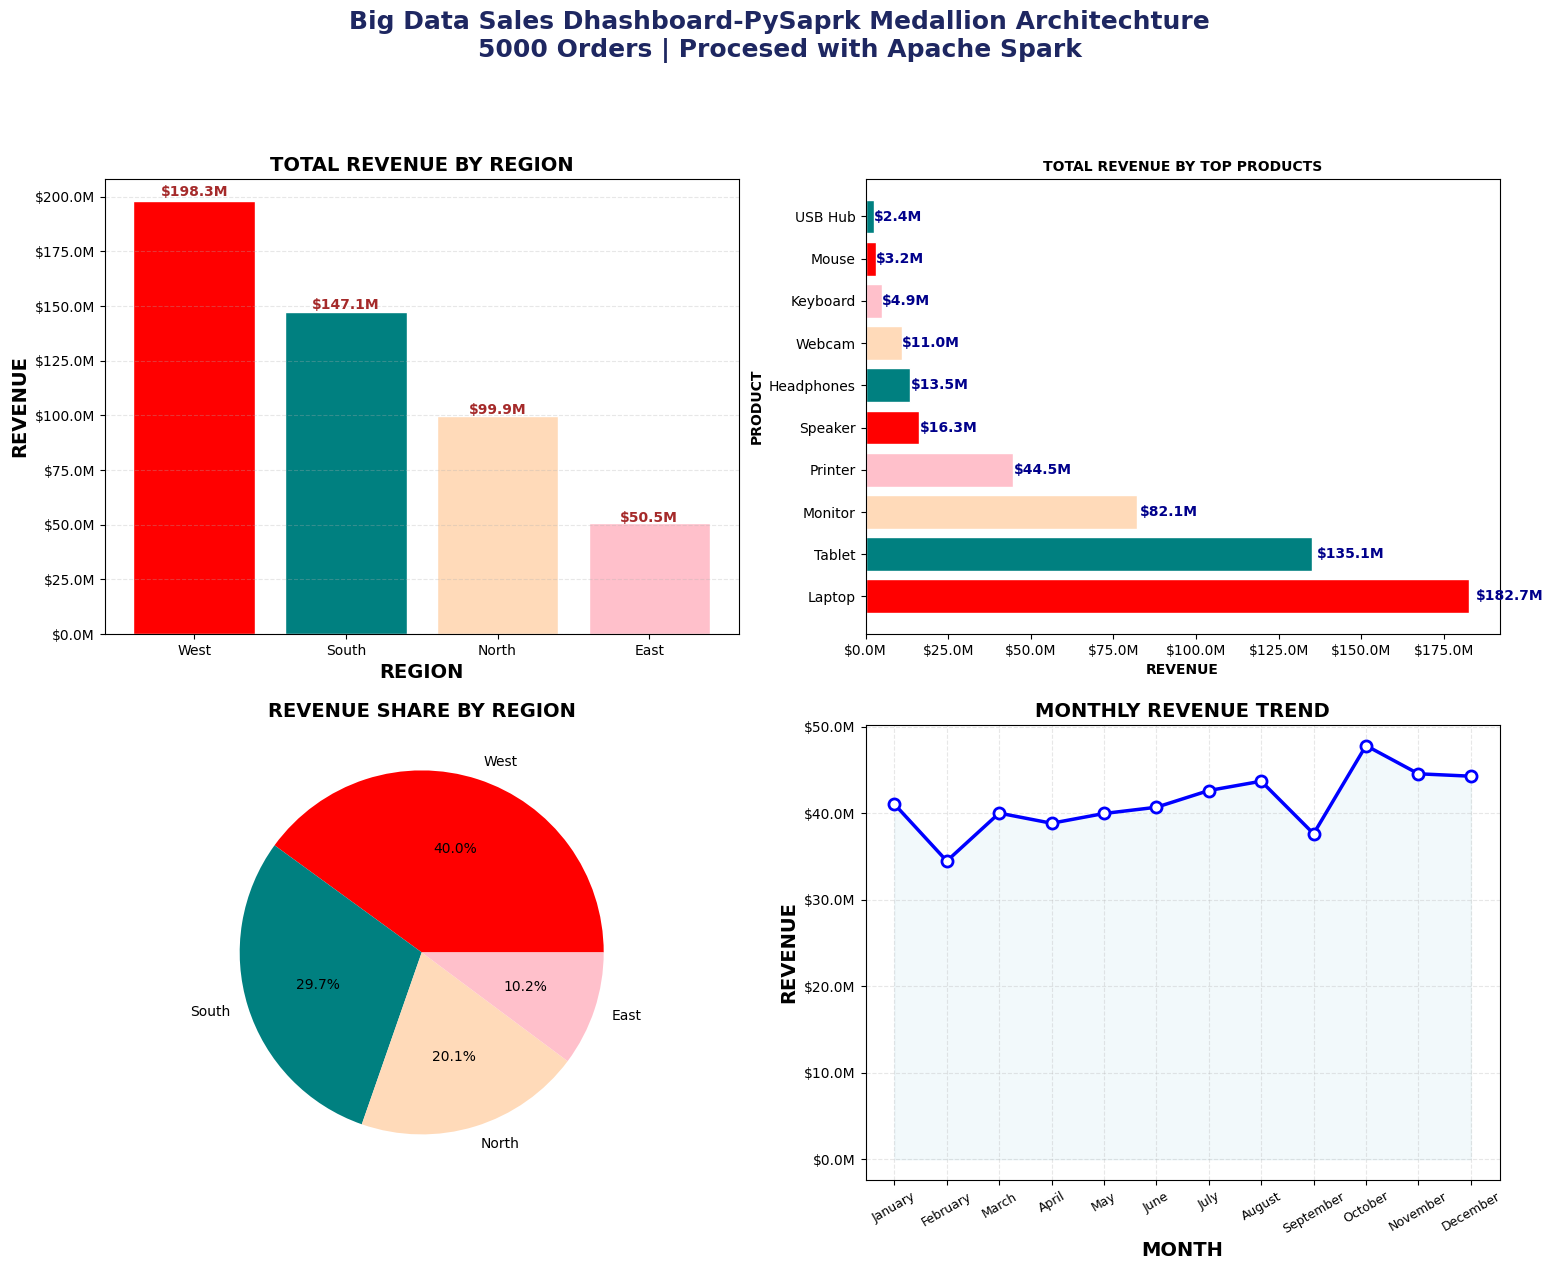

In [69]:
fig,axes=plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dhashboard-PySaprk Medallion Architechture\n'
    '5000 Orders | Procesed with Apache Spark',
    fontsize=18,fontweight='bold',color='#1E2761',y=1.01
)
colors4=['red','teal','peachpuff','pink','aliceblue']
ax1=axes[0,0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,f"${bar.get_height() / 1e6:.1f}M",
        ha='center',fontsize=10,fontweight='bold',color='brown')

ax1.set_title('TOTAL REVENUE BY REGION',fontsize=14,fontweight='bold')
ax1.set_ylabel('REVENUE',fontweight='bold',fontsize=14)
ax1.set_xlabel('REGION',fontweight='bold',fontsize=14)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')



ax2 = axes[0,1]
bars2 = ax2.barh(product_pd['product'],product_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars2:
    ax2.text( bar.get_width() * 1.01,bar.get_y() + bar.get_height()/2,f"${bar.get_width()/1e6:.1f}M",
        va='center',fontsize=10,fontweight='bold',color='darkblue')


ax2.set_title('TOTAL REVENUE BY TOP PRODUCTS',fontsize=10,fontweight='bold')
ax2.set_xlabel('REVENUE',fontweight='bold',fontsize=10)
ax2.set_ylabel('PRODUCT',fontweight='bold',fontsize=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))



ax3=axes[1,0]
pie=ax3.pie(region_pd['total_revenue'],labels=region_pd['region'],autopct='%1.1f%%',colors=colors4[:len(region_pd)])

ax3.set_title('REVENUE SHARE BY REGION',fontsize=14,fontweight='bold')


ax4=axes[1,1]
month_names=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_labels=[month_names[i-1] for i in monthly_pd['order_month']]
ax4.plot(monthly_labels,monthly_pd['monthly_revenue'],marker='o',linewidth=2.5,color='blue',markersize=8,markerfacecolor='white',markeredgewidth=2)
ax4.fill_between(range(len(monthly_pd)),monthly_pd['monthly_revenue'],color='lightblue',alpha=0.15)
ax4.set_title('MONTHLY REVENUE TREND',fontsize=14,fontweight='bold')
ax4.set_xlabel('MONTH',fontsize=14,fontweight='bold')
ax4.set_ylabel('REVENUE',fontsize=14,fontweight='bold')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax4.grid(alpha=0.3,linestyle='--')
ax4.tick_params(axis='x',rotation=30,labelsize=9)